In [ ]:
import os
import json

# ── 設定 Kaggle API ──────────────────────────────────────
os.makedirs('/root/.kaggle', exist_ok=True)

kaggle_config = {
    "username": "mark9991",
    "key": "b6e2c6a1f78e216568bc1494a933e278"
}

with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_config, f)

os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("✅ Kaggle API 設定完成！")

# ── 測試連線 ─────────────────────────────────────────────
!kaggle datasets list

# ── 下載資料集 ───────────────────────────────────────────
import kagglehub
path = kagglehub.dataset_download("fastpredictor/solar-power-generation-and-meteorological-data")
print("📁 資料集路徑:", path)

✅ Kaggle API 設定完成！
ref                                                                title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
algozee/teenager-menthal-healy                                     Social Media Impact on Teen Mental Health                16190  2026-04-05 08:04:21.823000           7350        179                1  
nalisha/job-salary-prediction-dataset                              Job Salary Prediction Dataset                          3144815  2026-03-16 19:54:33.843000          13662        307                1  
meruvakodandasuraj/youtube-trending-videos-20202026                YouTube Trending Videos 2020–2026                       843930  2026-04-13 11:10:04.770000            

Using Colab cache for faster access to the 'solar-power-generation-and-meteorological-data' dataset.
📁 資料集路徑 (for this cell): /kaggle/input/solar-power-generation-and-meteorological-data


,TimeStamp,Power,Temperature,Prectotland,Rhoa,Irradiance (G),Irradiance (A),Cloud,hour,day,month
0,2014-10-20 12:00:00,480.434911,30.565,0.0,1.138,706.618,1014.074,0.0,12,20,10
1,2014-10-20 13:00:00,441.050889,30.998,0.0,1.135,640.765,939.703,0.0,13,20,10
2,2014-10-20 14:00:00,349.804093,30.801,0.0,1.133,484.715,792.593,0.0,14,20,10
3,2014-10-20 15:00:00,218.694815,30.226,0.0,1.132,320.429,582.943,0.0,15,20,10
4,2014-10-20 16:00:00,98.935342,28.270,0.0,1.133,143.503,324.811,0.0,16,20,10
5,2014-10-20 17:00:00,14.467491,25.249,0.0,1.135,17.009,57.536,0.0,17,20,10
18,2014-10-21 06:00:00,4.964253,17.429,0.0,1.171,13.669,40.576,0.0,6,21,10
19,2014-10-21 07:00:00,64.771645,19.865,0.0,1.172,157.350,296.452,0.0,7,21,10
20,2014-10-21 08:00:00,169.613110,22.174,0.0,1.169,359.187,557.554,0.0,8,21,10
21,2014-10-21 09:00:00,275.624333,25.598,0.0,1.157,540.685,771.859,0.0,9,21,10


,TimeStamp,Power,Temperature,Prectotland,Rhoa,Irradiance (G),Irradiance (A),Cloud,hour,day,month
count,838,838.000000,838.000000,838.000000,838.000000,838.000000,838.000000,838.000000,838.000000,838.000000,838.000000
mean,2014-11-25 00:49:02.720763904,180.489953,20.584285,0.000434,1.173025,310.460810,507.147632,0.174881,11.729117,17.371122,11.244630
min,2014-10-20 12:00:00,0.011158,4.279000,0.000000,1.130000,0.000000,0.000000,0.000000,5.000000,1.000000,10.000000
25%,2014-11-06 20:15:00,53.184475,16.082000,0.000000,1.152000,89.412750,207.735250,0.000000,9.000000,10.000000,11.000000
50%,2014-11-24 10:30:00,172.737650,20.596000,0.000000,1.171000,313.886000,574.621000,0.000000,12.000000,19.000000,11.000000
75%,2014-12-13 07:45:00,301.332177,26.007250,0.000000,1.192000,509.938500,785.635250,0.180750,15.000000,25.000000,12.000000
max,2014-12-31 17:00:00,480.434911,32.357000,0.123000,1.237000,719.652000,1014.074000,0.982000,17.000000,31.000000,12.000000
std,NaN,132.136917,6.351925,0.005996,0.025821,219.223193,307.628430,0.309921,3.347552,8.958792,0.717465


,Missing Values
TimeStamp,0
Power,0
Temperature,0
Prectotland,0
Rhoa,0
Irradiance (G),0
Irradiance (A),0
Cloud,0
hour,0
day,0


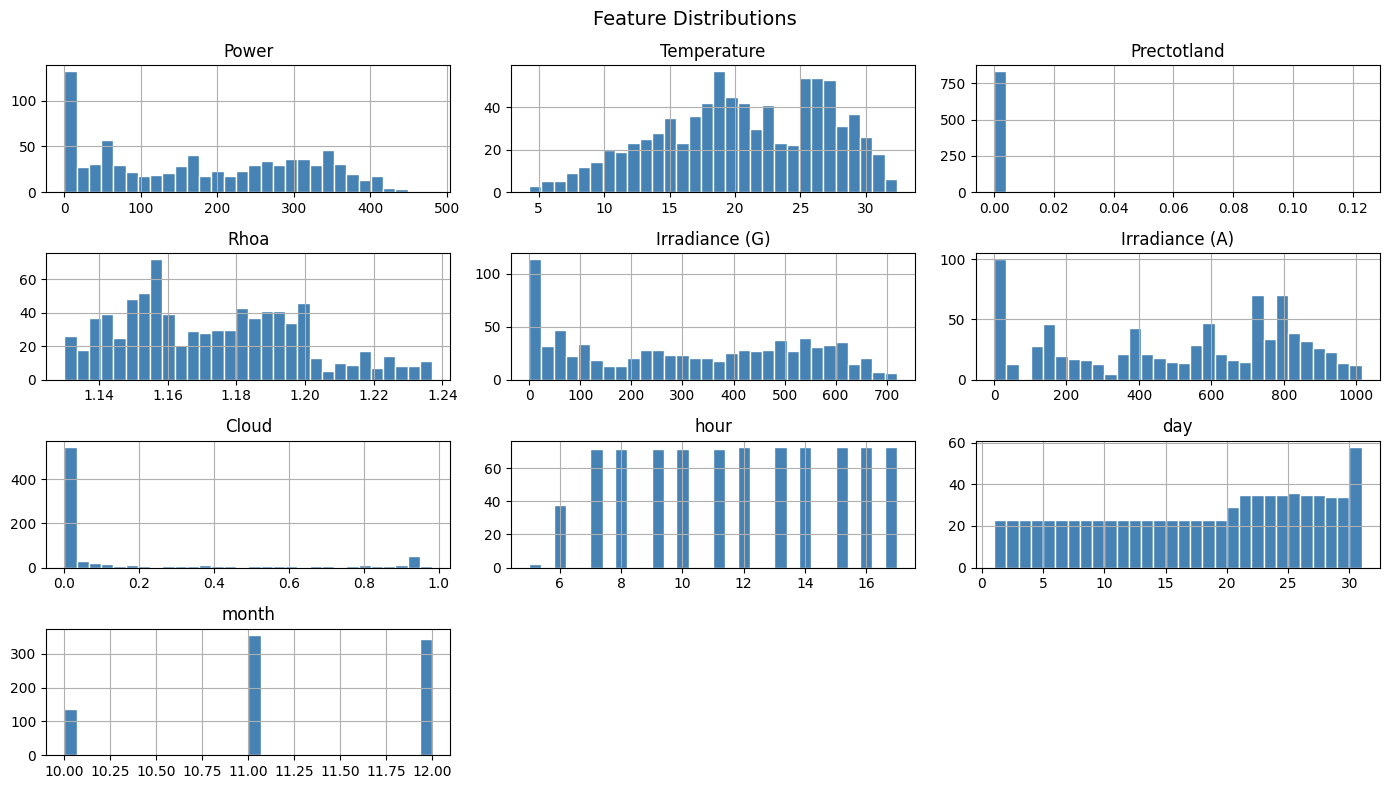

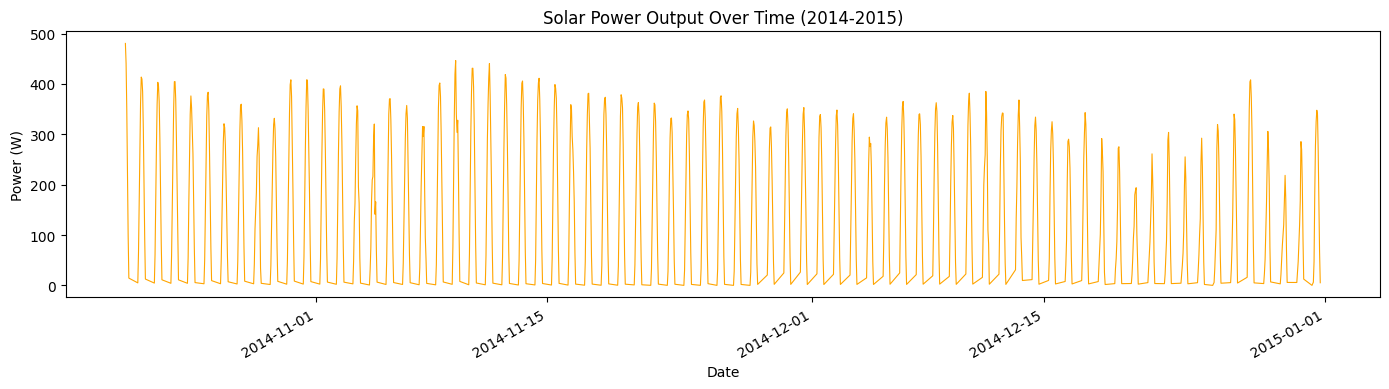

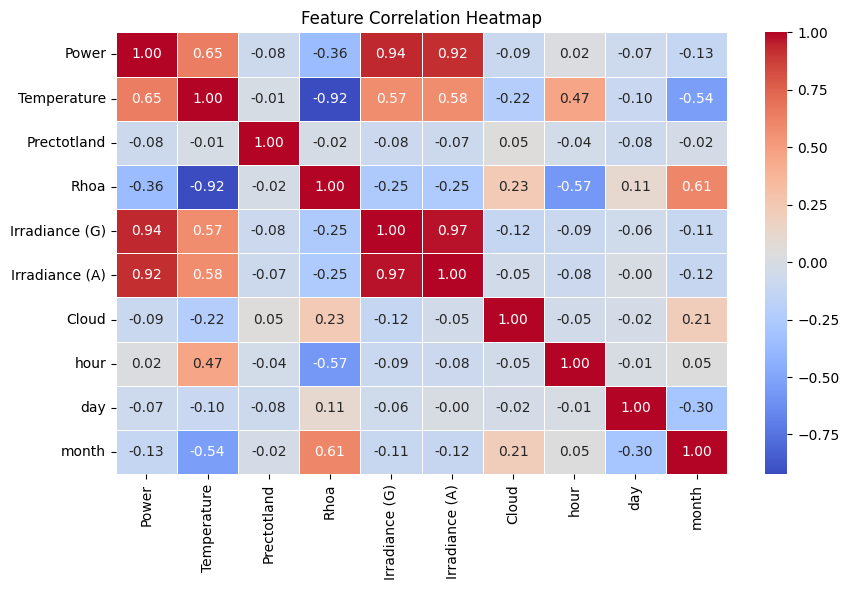

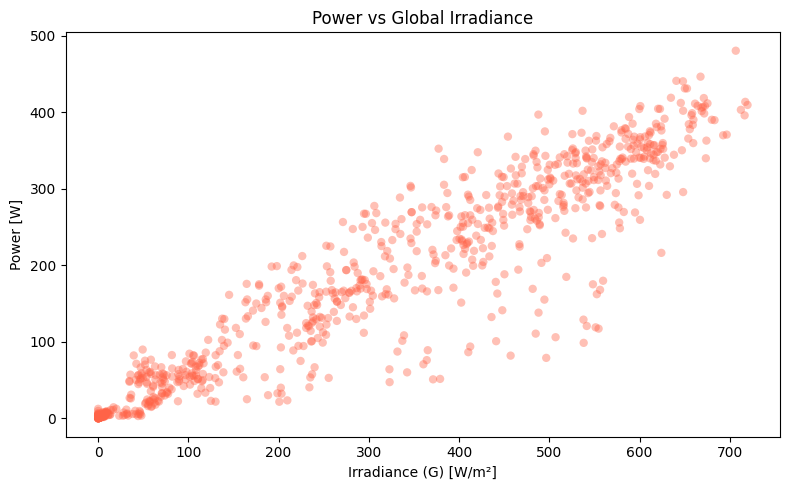

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub # Import kagglehub for dataset_download

# Ensure 'path' variable is correctly set for the solar power dataset.
# Explicitly set path to avoid issues if it was overwritten.
path = kagglehub.dataset_download("fastpredictor/solar-power-generation-and-meteorological-data")
print("📁 資料集路徑 (for this cell):", path)

# --- Re-load and preprocess df to ensure correct data is used for this cell ---
# List files in the dataset path
files = [f for f in os.listdir(path) if f.endswith('.csv')]
# Read the CSV (assuming the first CSV file is the correct one)
df = pd.read_csv(os.path.join(path, files[0]))

# Data Preprocessing steps (from ffwj-7QvKhih)
df = df.dropna() # Drop rows with any missing values
df['TimeStamp'] = pd.to_datetime(df['TimeStamp']) # Convert TimeStamp to datetime objects
df['hour'] = df['TimeStamp'].dt.hour # Extract hour
df['day'] = df['TimeStamp'].dt.day # Extract day
df['month'] = df['TimeStamp'].dt.month # Extract month
df = df[df['Power'] > 0] # Keep only data points where Power is greater than 0 (daytime)
# ------------------------------------------------------------------------------

# ── 1. 基本資料表顯示（互動式）──────────────────────────
display(df.head(10))          # 前10筆，有格式的表格
display(df.describe())        # 統計摘要表

# ── 2. 缺失值表 ──────────────────────────────────────────
display(df.isnull().sum().to_frame('Missing Values'))

# ── 3. 各欄位分佈圖 ──────────────────────────────────────
df.select_dtypes(include='number').hist(figsize=(14, 8), bins=30, color='steelblue', edgecolor='white')
plt.suptitle('Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

# ── 4. 發電量隨時間變化 ───────────────────────────────────
plt.figure(figsize=(14, 4))
df.set_index('TimeStamp')['Power'].plot(color='orange', linewidth=0.8)
plt.title('Solar Power Output Over Time (2014-2015)')
plt.ylabel('Power (W)')
plt.xlabel('Date')
plt.tight_layout()
plt.show()

# ── 5. 相關係數熱圖 ───────────────────────────────────────
plt.figure(figsize=(9, 6))
sns.heatmap(df.select_dtypes(include='number').corr(),
            annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# ── 6. 發電量 vs 輻照度 散點圖 ───────────────────────────
plt.figure(figsize=(8, 5))
plt.scatter(df['Irradiance (G)'], df['Power'], alpha=0.4, color='tomato', edgecolors='none')
plt.xlabel('Irradiance (G) [W/m²]')
plt.ylabel('Power [W]')
plt.title('Power vs Global Irradiance')
plt.tight_layout()
plt.show()

找到的檔案: ['Lahore_Single_Panel_Dataset_with_Meteorological_Datas.csv']
             TimeStamp       Power  Temperature  Prectotland   Rhoa  \
0  2014-10-20 12:00:00  480.434911       30.565          0.0  1.138   
1  2014-10-20 13:00:00  441.050889       30.998          0.0  1.135   
2  2014-10-20 14:00:00  349.804093       30.801          0.0  1.133   
3  2014-10-20 15:00:00  218.694815       30.226          0.0  1.132   
4  2014-10-20 16:00:00   98.935342       28.270          0.0  1.133   

   Irradiance (G)  Irradiance (A)  Cloud  
0         706.618        1014.074    0.0  
1         640.765         939.703    0.0  
2         484.715         792.593    0.0  
3         320.429         582.943    0.0  
4         143.503         324.811    0.0  
Shape: (1745, 8)
有效筆數: 838


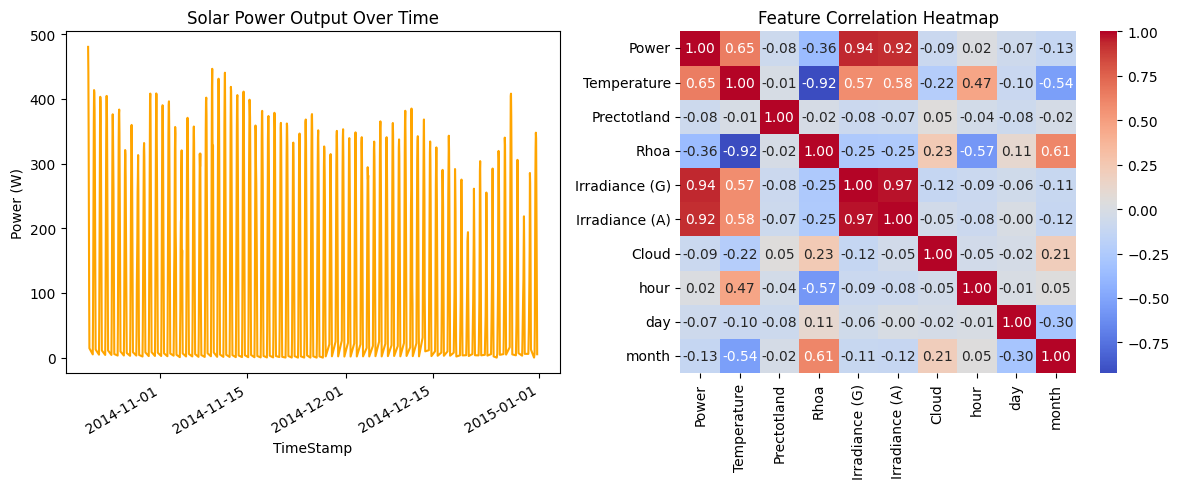

訓練集: (670, 8), 測試集: (168, 8)

=== 模型評估結果 ===
RMSE : 35.81 W
MAE  : 21.21 W
R²   : 0.9278


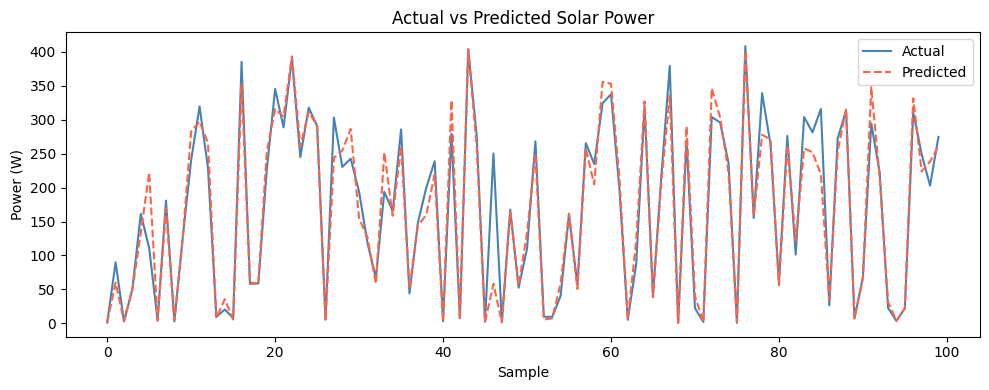

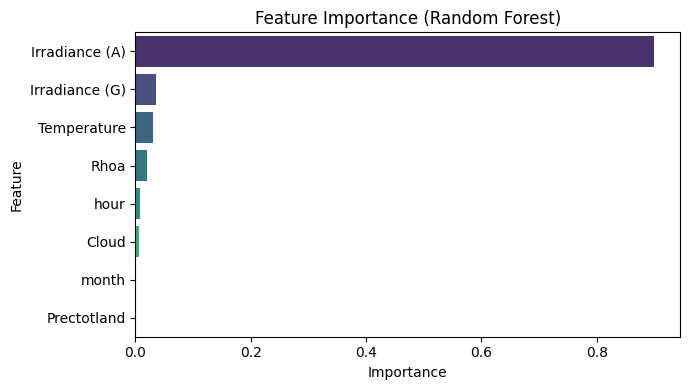

In [ ]:
# ── 匯入套件 ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ── 讀取資料（從 kagglehub 下載的路徑）───────────────────
files = [f for f in os.listdir(path) if f.endswith('.csv')]
print("找到的檔案:", files)

df = pd.read_csv(os.path.join(path, files[0]))
print(df.head())
print("Shape:", df.shape)

# ── 資料前處理 ────────────────────────────────────────────
df = df.dropna()
df['TimeStamp'] = pd.to_datetime(df['TimeStamp'])
df['hour']  = df['TimeStamp'].dt.hour
df['day']   = df['TimeStamp'].dt.day
df['month'] = df['TimeStamp'].dt.month
df = df[df['Power'] > 0]  # 只保留白天
print("有效筆數:", len(df))

# ── EDA ───────────────────────────────────────────────────
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
df.set_index('TimeStamp')['Power'].plot(title='Solar Power Output Over Time', color='orange')
plt.ylabel('Power (W)')
plt.subplot(1, 2, 2)
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# ── 特徵選擇與切分 ────────────────────────────────────────
feature_cols = ['Irradiance (G)', 'Irradiance (A)', 'Temperature',
                'Cloud', 'Rhoa', 'Prectotland', 'hour', 'month']
X = df[feature_cols]
y = df['Power']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print(f"訓練集: {X_train.shape}, 測試集: {X_test.shape}")

# ── 模型訓練 ──────────────────────────────────────────────
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# ── 模型評估 ──────────────────────────────────────────────
y_pred = rf_model.predict(X_test)
print("\n=== 模型評估結果 ===")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.2f} W")
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.2f} W")
print(f"R²   : {r2_score(y_test, y_pred):.4f}")

# ── 視覺化 ────────────────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.plot(y_test.values[:100], label='Actual', color='steelblue')
plt.plot(y_pred[:100], label='Predicted', color='tomato', linestyle='--')
plt.title('Actual vs Predicted Solar Power')
plt.xlabel('Sample')
plt.ylabel('Power (W)')
plt.legend()
plt.tight_layout()
plt.show()

# 特徵重要性
feat_df = pd.DataFrame({'Feature': feature_cols, 'Importance': rf_model.feature_importances_})
feat_df = feat_df.sort_values('Importance', ascending=False)
plt.figure(figsize=(7, 4))
sns.barplot(data=feat_df, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('Feature Importance (Random Forest)')
plt.tight_layout()
plt.show()